# Point-charge simulations of V3Si μSR spectra

As a comparison with DFT calculation, whose results are very accurate in describing the muon polarization in A15 compounds, we show example here the simulation of the μSR spectra of V3Si using the point-charge model.

In [1]:
import numpy as np
from copy import deepcopy

# for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

from muonscripts.io_tools.load_relax import load_relax
from muonscripts.io_tools.load_relax import save_relax_results
from muonscripts.io_tools.load_relax import load_relax_results
from muonscripts.io_tools.find_qe_files import select_groups
from muonscripts.io_tools.find_qe_files import get_relax_after_run
from muonscripts.io_tools.find_qe_files import print_relax_summary
from muonscripts.io_tools.find_qe_files import load_relax_from_folder

from muonscripts.undi_tools.second_moments_avg import second_moments_fn
from muonscripts.undi_tools.second_moments import zero_field_distribution_powder

from muonscripts.undi_tools.atoms_scaling import scale_neighbors, partition_into_shells
from muonscripts.undi_tools.atoms_scaling import only_muon_cluster, compute_zeta_cluster

from muonscripts.undi_tools.atoms import build_undi_neighbors, build_undi_neighbors_from_file
from muonscripts.undi_tools.atoms import complete_undi_neighbors, neighbors_hilbert_dimension

from muonscripts.efg.point_charge import compute_efg
from muonscripts.efg.point_charge import sphere_radius_convergence
from muonscripts.efg.point_charge import build_point_charge_efg_neighbors

# from muonscripts.efg.utils import nu_Q, quadrupole_frequencies, get_omegaQ_mu
# from muonscripts.efg.point_charge import compute_efg, point_charge_EFG, diagonalize_EFG, atom_dict_EFG

from muonscripts.muon_tools.displacements import radial_to_dict
from muonscripts.muon_tools.displacements import max_displacement
from muonscripts.muon_tools.displacements import select_radial_displacement

from muonscripts.muon_tools.aiida_muon.sites_supercells import gensup
from muonscripts.muon_tools.aiida_muon.sites_supercells import niche_add_impurities
from muonscripts.muon_tools.aiida_muon.sites_supercells import compute_suggest_supercell_size

from muonscripts.muon_tools.aiida_muon.distortions import get_distortions
from muonscripts.muon_tools.aiida_muon.clustering import get_clustering_after_run_from_data

from muonscripts.muon_tools.aiida_muon.clustering_report import print_clustering_summary

In [3]:
def load_raw_data_only(filename, x_min=0):
    """Reads the first 2-3 columns (xData, Data, [errData]) of a muSR
    data file, ignoring any other (e.g. theory) columns."""
    import pandas as pd
    
    df = pd.read_csv(filename, skipinitialspace=True)
    df = df.replace(r"^\s*$", np.nan, regex=True)
    cols = list(df.columns[:3])
    d = df[cols].dropna()
    xData = d[cols[0]].to_numpy(dtype=float)
    yData = d[cols[1]].to_numpy(dtype=float)
    errData = d[cols[2]].to_numpy(dtype=float) if len(cols) > 2 else None
    if x_min is not None:
        keep = xData >= x_min
        xData, yData = xData[keep], yData[keep]
        if errData is not None:
            errData = errData[keep]
    return xData, yData, errData


def _ordered_legend(ax, order_list, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()

    def priority(label):
        for i, key in enumerate(order_list):
            if key in label:
                return i
        return len(order_list)

    entries = sorted(
        zip(handles, labels),
        key=lambda e: priority(e[1])
    )

    handles, labels = zip(*entries)

    return ax.legend(handles, labels, **legend_kwargs)

In [4]:
def compare_neighbors_positions(original, scaled):
    """
    Compare nuclear positions before and after scaling.
    """

    for old, new in zip(original, scaled):

        label = old["Label"]

        if label == "mu":
            continue

        r_old = np.linalg.norm(old["Position"])
        r_new = np.linalg.norm(new["Position"])
        rel_dif = np.linalg.norm(new["Position"]-old["Position"])

        ang = 1e-10
        print(
            f"{label:>5s}  "
            f"|R_old| = {r_old/ang:.6f} Å   "
            f"|R_new| = {r_new/ang:.6f} Å   "
            f"|R_new|-|R_old| = {(r_new-r_old)/ang: .6f} Å   "
            f"|R_new-R_old| = {rel_dif/ang:.6f} Å   "
            f"|R_new|/|R_old| = {r_new/r_old:.4f}"
        )

In [5]:
def powder_celio_signal(
    neighbors, 
    tlist, 
    k=2, 
    nrep=1,
    single_precision=False, 
    algorithm='light',
    log_level='',
    undi_path='/home/misah/projects/myproject/undi'
):
    """Powder-averaged P_z^mu(t) via undi.py's celio_on_steroids(), using
    the SAME exact 3-orthogonal-axis trick as the exact-diagonalization
    path elsewhere in this thread (mathematically exact for zero-field
    muon depolarization, independent of which method solves the
    dynamics underneath -- see wilkinson_prl_example.py's derivation).

    REQUIRES the compiled backend (fast_quantum_light or similar) that
    ships with the full `undi` package -- NOT importable from just
    undi.py + isotopes.py as used elsewhere in this thread. If you see
    ImportError here, you need `pip install undi` (or build the C++
    extensions from the undi source repo) rather than just using the
    loose undi.py file.

    nrep : int
        Number of independent Celio stochastic repeats to average over
        (in ADDITION to averaging over the 3 powder directions) -- more
        repeats reduce the Monte Carlo noise in the result. The paper's
        own SM mentions similar repeat-averaging for their Celio-based
        A15 simulations.
    """
    # Importing stuff...
    try:
        from undi import MuonNuclearInteraction
    except (ImportError, ModuleNotFoundError):
        import sys
        sys.path.append(undi_path)
        from undi import MuonNuclearInteraction

    signal = np.zeros(len(tlist))
    for direction in ([1, 0, 0], [0, 1, 0], [0, 0, 1]): # simple powder average
        NS = MuonNuclearInteraction(neighbors, log_level=log_level)
        NS.translate_rotate_sample_vec(direction)   # rotates geometry directly
        for _ in range(nrep):
            signal += NS.celio_on_steroids(
                tlist, k=k, single_precision=single_precision, progress=False, algorithm=algorithm
            )
    return signal / (3 * nrep)

In [6]:
import os
dpath='./'

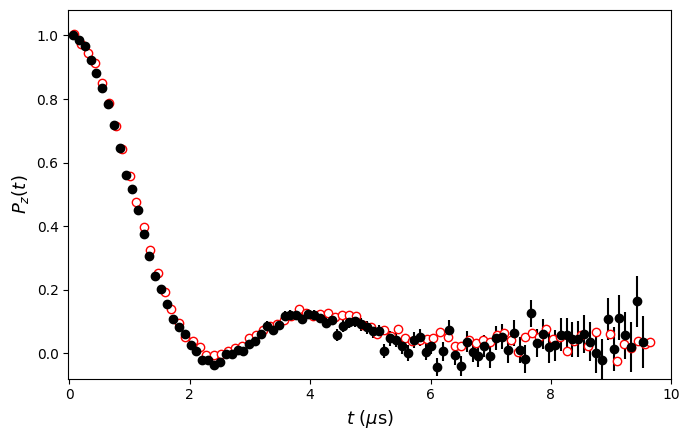

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))

file = 'V3Si_ZFmuSRdata_23K.dat'
file = os.path.join(dpath, file)
data = np.loadtxt(
    file,
    delimiter=",",
    # skiprows=1
)
t = data[:, 0]
y = data[:, 1]
# print(len(y))
ax.errorbar(t, y, yerr=None, fmt='o', color='k', mfc='white', mec='r', fillstyle=None, ms=6)

file = 'V3Si_ZFmuSRdata_unfiltered_23K.dat'
file = 'V3Si_ZFmuSRdata_unfiltered_23K_v2.dat'
file = os.path.join(dpath, file)
xData, yData, errData = load_raw_data_only(file, x_min=0.0)   # drop the t<0 "prompt" artifact bin
# print(len(yData))
ax.errorbar(xData, yData/yData.max(), yerr=errData/yData.max(), fmt='o', color='k', alpha=1.0, ms=6, label='data')

ax.set_xlabel(r"$t$ ($\mu$s)", fontsize=13)
ax.set_ylabel(r"$P_z(t)$", fontsize=13)

ax.set_xlim([-0.02, 10.0])
ax.set_ylim([-0.08, 1.08])

plt.tight_layout()
plt.show()

In [8]:
filename = "V3Si.cif"
filename = os.path.join(dpath, filename)
atoms = read_cif(filename) # or with read_from_file
# or with
filename = "V3Si_GEOMETRY.OUT"
filename = os.path.join(dpath, filename)
atoms = read_from_file(filename, format="elk") # you can parse **read_kwargs depending on the type of the I/O

atoms

Atoms(symbols='V6Si2', pbc=True, cell=[4.724899935457895, 4.724899935457895, 4.724899935457895], initial_magmoms=...)

In [9]:
muon_position = [0.00, 0.25, 0.50] # site A
# muon_position = [0.25, 0.25, 0.25] # site B

quad_moments_overrides = {'V': -0.052e-28, 'Nb': -0.32e-28}
V3Si_charges = {'V': +1, 'Si': -3}

In [10]:
file = "V3Si_GEOMETRY.OUT"
file = os.path.join(dpath, file)

muon_position = np.array([0.00, 0.25, 0.50]) # site A
Q_overrides = {'V': -0.052e-28, 'Nb': -0.32e-28}
V3Si_charges = {'V': +1, 'Si': -3}
########################################################

ALL_CLUSTERS = {}
S2_VALUES = {}

V3SI_UNPERTURBED_NEIGHBORS = {
    'ALL_CLUSTERS': {},
    'S2_VALUES': {},
    'SIGNALS': {}
}

cutoffs_settings = {
    ## "name" : [cutoffs, max_cutoff]
    'NN':  [{'V': 2.00}, 10],
    'NNN': [{'V': 3.50}, 10],
    'INF': [{'V': 40.0}, 40],
}

for name, (cutoffs, inf_cutoff) in cutoffs_settings.items():
    # print(name, cutoffs, inf_cutoff)
    print(f"== Building neighbor cluster for: {name} ==")
    neighbors = build_undi_neighbors_from_file(
        file,
        muon_position,
        cutoffs=cutoffs,
        inf_cutoff=inf_cutoff,
        efg_tensors=None,
        efg_factor=1.0,
        gamma_overrides=None,
        isotope_overrides=None,
        quadrupole_moments_overrides=Q_overrides,
        verbose_neighbors=False,
        format='elk'
        # **read_kwargs,
    )

    # complete missing nuclear properties
    neighbors = complete_undi_neighbors(neighbors, log_level="")

    ALL_CLUSTERS[name] = deepcopy(neighbors)

    dim = neighbors_hilbert_dimension(neighbors)
    if dim < 1e6:
        print(f"---- The Hilbert space dimension is: {dim} x {dim} ----")
    else:
        import math
        # print(f"---- The Hilbert space dimension is: {dim:.3e} x {dim:.3e} ----")
        print(f"---- The Hilbert space dimension is ≈: 10^{math.log10(dim):.2f} x 10^{math.log10(dim):.2f} ----")

    # # calculate second moments
    if name != "NNN":
        S2_VALUES[name] = zero_field_distribution_powder(neighbors)

MU_ATOMS = only_muon_cluster(ALL_CLUSTERS["NN"])
ALL_CLUSTERS['MU'] = deepcopy(MU_ATOMS)

# Bare NN (i.e no muon)
shells = partition_into_shells(
    MU_ATOMS[0],
    [MU_ATOMS, ALL_CLUSTERS["NN"]],
    rtol=1e-4,
)
ALL_CLUSTERS['NN_BARE'] = deepcopy(shells[1])

# Bare NNN (i.e no muon and no NN atoms, only NNN)
shells = partition_into_shells(
    MU_ATOMS[0],
    [ALL_CLUSTERS["NN"], ALL_CLUSTERS["NNN"]],
    rtol=1e-4,
)
ALL_CLUSTERS['NNN_BARE'] = deepcopy(shells[1])

# calculate second moments (MUON + BARE NNN atoms)
S2_VALUES["NNN"] = zero_field_distribution_powder(
    MU_ATOMS + shells[1]
)

ZETA = (S2_VALUES["NNN"] / (S2_VALUES["INF"] - S2_VALUES["NN"])) ** (1 / 6)
# or with
ZETA = compute_zeta_cluster(ALL_CLUSTERS['INF'], [ALL_CLUSTERS['NN'], ALL_CLUSTERS['NNN']], rtol=1e-4)

print(f'---- calculated  ZETA (ζ)  parameter ζ = {ZETA:.4f} (paper: 0.8150) ----')

V3SI_UNPERTURBED_NEIGHBORS['ZETA'] = ZETA
V3SI_UNPERTURBED_NEIGHBORS['S2_VALUES'] = S2_VALUES
V3SI_UNPERTURBED_NEIGHBORS['ALL_CLUSTERS'] = ALL_CLUSTERS

Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V


== Building neighbor cluster for: NN ==
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
---- The Hilbert space dimension is: 8192 x 8192 ----
== Building neighbor cluster for: NNN ==
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
---- The Hilbert space dimension is ≈: 10^7.53 x 10^7.53 ----
== Building neighbor cluster for: INF ==
[override/insert] quadrupole m

Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V


[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadru

Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole m

---- The Hilbert space dimension is ≈: 10^13799.52 x 10^13799.52 ----
---- calculated  ZETA (ζ)  parameter ζ = 0.8151 (paper: 0.8150) ----


In [11]:
V3SI_UNPERTURBED_NEIGHBORS.get("ZETA"), V3SI_UNPERTURBED_NEIGHBORS.get("S2_VALUES")
V3SI_UNPERTURBED_NEIGHBORS.keys()
V3SI_UNPERTURBED_NEIGHBORS['ALL_CLUSTERS']['NN'][0].copy()

{'Position': array([0., 0., 0.]),
 'Label': 'mu',
 'Spin': 0.5,
 'Gamma': 851615459.5446056}

In [12]:
# quadrupolar_cluster = build_point_charge_efg_neighbors(
#     atoms,
#     neighbors=V3SI_UNPERTURBED_NEIGHBORS['ALL_CLUSTERS']['NN'],
#     muon_position=muon_position,
#     atomic_charges=V3Si_charges,
#     sphere_radius=50,
#     include_nuclear_efg=False,
#     remove_efg_noise=False,
#     efg_verbose=False
# )

# unscaled = quadrupolar_cluster.copy()
# scaled = scale_neighbors(
#     unscaled, scale=1+(0.088/100), mode="multiplicative", include_muon=True
# )

# unscaled
# scaled

# compare_neighbors_positions(unscaled, scaled)

In [13]:
# Time values, in seconds
tlist = np.linspace(0, 10e-6, 1000)
tlist = np.linspace(0.0, 10e-6, 101)
tlist_us = tlist*1e6

In [14]:
type  = 'NN'
efg_bool_list = [False, True]
SIGNALS = {
    type: {}
}
neighbors =  V3SI_UNPERTURBED_NEIGHBORS['ALL_CLUSTERS'][type]
for include_efg in efg_bool_list:
    neighbors =  neighbors.copy()
    neighbors = scale_neighbors(
        neighbors, scale=1+(0.0/100), mode="multiplicative", include_muon=True
    )
    quadrupolar_neighbors = build_point_charge_efg_neighbors(
        atoms,
        neighbors=neighbors.copy(),
        muon_position=muon_position,
        atomic_charges=V3Si_charges,
        sphere_radius=50,
        include_nuclear_efg=include_efg,
        remove_efg_noise=True,
        efg_factor=1.0+(0/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
        efg_verbose=False,
        include_muon=True
    )

    signals = powder_celio_signal(
        quadrupolar_neighbors, tlist=tlist, k=4, nrep=4, single_precision=True, algorithm='fast')

    name = "WITH_EFG" if include_efg else "WITHOUT_EFG"
    SIGNALS[type][name] = signals
    if include_efg:
        V3SI_UNPERTURBED_NEIGHBORS['ALL_CLUSTERS'][type+'_'+name] = quadrupolar_neighbors

V3SI_UNPERTURBED_NEIGHBORS["SIGNALS"]["tlist"] = tlist
V3SI_UNPERTURBED_NEIGHBORS["SIGNALS"]["data"] = SIGNALS

Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, ove

In [15]:
SIGNALS['NN'].keys()
SIGNALS.keys()
V3SI_UNPERTURBED_NEIGHBORS.keys()
V3SI_UNPERTURBED_NEIGHBORS["SIGNALS"].keys()
V3SI_UNPERTURBED_NEIGHBORS["SIGNALS"]["data"]["NN"].keys()

dict_keys(['WITHOUT_EFG', 'WITH_EFG'])

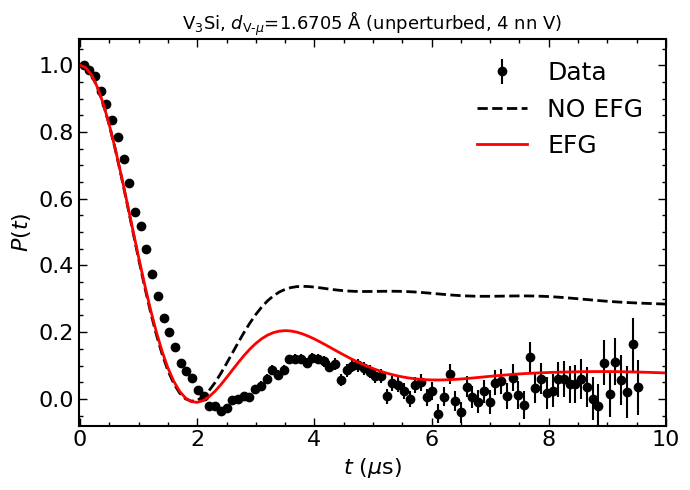

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

file = 'V3Si_ZFmuSRdata_23K.dat'
file = os.path.join(dpath, file)
data = np.loadtxt(
    file,
    delimiter=",",
    # skiprows=1
)
t = data[:, 0]
y = data[:, 1]
# print(len(y))
# ax.errorbar(t, y, yerr=None, fmt='o', color='k', mfc='white', mec='r', fillstyle=None, ms=6)

file = 'V3Si_ZFmuSRdata_unfiltered_23K.dat'
file = 'V3Si_ZFmuSRdata_unfiltered_23K_v2.dat'
file = os.path.join(dpath, file)
xData, yData, errData = load_raw_data_only(file, x_min=0.0)   # drop the t<0 "prompt" artifact bin
# print(len(yData))
ax.errorbar(xData, yData/yData.max(), yerr=errData/yData.max(), fmt='o', color='k', alpha=1.0, ms=6, label='Data')

# simulations
tlist_us = V3SI_UNPERTURBED_NEIGHBORS["SIGNALS"]["tlist"]
simulations = V3SI_UNPERTURBED_NEIGHBORS["SIGNALS"]["data"]["NN"]
ax.errorbar(tlist_us*1e6, simulations['WITHOUT_EFG'], color='k', ls='--', lw=2, label='NO EFG')
ax.errorbar(tlist_us*1e6, simulations['WITH_EFG'], color='r', ls='-', lw=2, label='EFG')

fontsize=16

ax.set_title(r"V$_3$Si, $d_{\mathrm{V}\text{-}{\mu}}$=1.6705 Å (unperturbed, 4 nn V)", fontsize=fontsize-3)

ax.set_xlabel(r"$t$ ($\mu$s)", fontsize=fontsize)
ax.set_ylabel(r"$P(t)$", fontsize=fontsize)

ax.set_xlim([-0.02, 10.0])
ax.set_ylim([-0.08, 1.08])


for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.minorticks_on()
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=6,
    width=1.0,
    labelsize=fontsize,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=1.0,
)

prop={'size': 18, 'weight':'normal'}
handler_map={
    tuple: matplotlib.legend_handler.HandlerTuple(ndivide=5, pad=1), # ndivide=None
}
_ordered_legend(ax, order_list=('Data', ), prop=prop, frameon=False, handler_map=handler_map)
# ax.legend()

plt.tight_layout()
plt.show()

In [17]:
file = 'V3Si_QE_RELAX3x3x3_SITE_A.OUT'
file = os.path.join(dpath, file)
atoms_rlx_mu = read_from_file(file, format="espresso-out", index=-1)

atoms_rlx = atoms_rlx_mu.copy()

muon_idx = np.flatnonzero(atoms_rlx.numbers == 1)
if len(muon_idx) != 1:
    raise ValueError(f"Expected exactly one muon, found {len(muon_idx)}.")
muon_idx = muon_idx.item()
muon_position_rlx = atoms_rlx.get_scaled_positions()[muon_idx]
del atoms_rlx[muon_idx]

atoms_rlx, muon_position_rlx

(Atoms(symbols='Si54V162', pbc=True, cell=[14.179169945176634, 14.179169945176634, 14.179169945176634]),
 array([1.66667274e-01, 1.82740000e-06, 8.33332099e-02]))

In [18]:
Q_overrides = {'V': -0.052e-28, 'Nb': -0.32e-28}
V3Si_charges = {'V': +1, 'Si': -3}
########################################################

ALL_CLUSTERS = {}
S2_VALUES = {}

V3SI_PERTURBED_NEIGHBORS = {
    'ALL_CLUSTERS': {},
    'S2_VALUES': {},
    'SIGNALS': {}
}

cutoffs_settings = {
    ## "name" : [cutoffs, max_cutoff]
    'NN':  [{'V': 2.00}, 10],
    'NNN': [{'V': 3.50}, 10],
    'INF': [{'V': 40.0}, 40],
}

for name, (cutoffs, inf_cutoff) in cutoffs_settings.items():
    # print(name, cutoffs, inf_cutoff)
    print(f"== Building neighbor cluster for: {name} ==")
    neighbors = build_undi_neighbors(
        atoms_rlx,
        muon_position_rlx,
        cutoffs=cutoffs,
        inf_cutoff=inf_cutoff,
        efg_tensors=None,
        efg_factor=1.0,
        gamma_overrides=None,
        isotope_overrides=None,
        quadrupole_moments_overrides=Q_overrides,
        verbose_neighbors=False,
        # format='elk'
        # **read_kwargs,
    )

    # complete missing nuclear properties
    neighbors = complete_undi_neighbors(neighbors, log_level="")

    ALL_CLUSTERS[name] = deepcopy(neighbors)

    dim = neighbors_hilbert_dimension(neighbors)
    if dim < 1e6:
        print(f"---- The Hilbert space dimension is: {dim} x {dim} ----")
    else:
        import math
        # print(f"---- The Hilbert space dimension is: {dim:.3e} x {dim:.3e} ----")
        print(f"---- The Hilbert space dimension is ≈: 10^{math.log10(dim):.2f} x 10^{math.log10(dim):.2f} ----")

    # # calculate second moments
    if name != "NNN":
        S2_VALUES[name] = zero_field_distribution_powder(neighbors)

MU_ATOMS = only_muon_cluster(ALL_CLUSTERS["NN"])
ALL_CLUSTERS['MU'] = deepcopy(MU_ATOMS)

# Bare NN (i.e no muon)
shells = partition_into_shells(
    MU_ATOMS[0],
    [MU_ATOMS, ALL_CLUSTERS["NN"]],
    rtol=1e-4,
)
ALL_CLUSTERS['NN_BARE'] = deepcopy(shells[1])

# Bare NNN (i.e no muon and no NN atoms, only NNN)
shells = partition_into_shells(
    MU_ATOMS[0],
    [ALL_CLUSTERS["NN"], ALL_CLUSTERS["NNN"]],
    rtol=1e-4,
)
ALL_CLUSTERS['NNN_BARE'] = deepcopy(shells[1])

# calculate second moments (MUON + BARE NNN atoms)
S2_VALUES["NNN"] = zero_field_distribution_powder(
    MU_ATOMS + shells[1]
)

ZETA = (S2_VALUES["NNN"] / (S2_VALUES["INF"] - S2_VALUES["NN"])) ** (1 / 6)
# or with
ZETA = compute_zeta_cluster(ALL_CLUSTERS['INF'], [ALL_CLUSTERS['NN'], ALL_CLUSTERS['NNN']], rtol=1e-4)

print(f'---- calculated  ZETA (ζ)  parameter ζ = {ZETA:.4f} (paper: 0.8150) ----')

V3SI_PERTURBED_NEIGHBORS['ZETA'] = ZETA
V3SI_PERTURBED_NEIGHBORS['S2_VALUES'] = S2_VALUES
V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS'] = ALL_CLUSTERS

== Building neighbor cluster for: NN ==


Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V


[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
---- The Hilbert space dimension is: 8192 x 8192 ----
== Building neighbor cluster for: NNN ==


Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V


[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
---- The Hilbert space dimension is ≈: 10^7.53 x 10^7.53 ----
== Building neighbor cluster for: INF ==
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: -5.200000e-30 m^2
[override/insert] quadrupole moment for V: 

Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole moment for V
Warning, overriding quadrupole m

---- The Hilbert space dimension is ≈: 10^13734.49 x 10^13734.49 ----
---- calculated  ZETA (ζ)  parameter ζ = 0.8132 (paper: 0.8150) ----


In [19]:
type  = 'NN'
efg_bool_list = [False, True]
SIGNALS = {
    type: {},
    'ALL_V': {}
}
neighbors =  V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS'][type]
for include_efg in efg_bool_list:
    neighbors =  neighbors.copy()
    neighbors = scale_neighbors(
        neighbors, scale=1+(0.0/100), mode="multiplicative", include_muon=True
    )
    quadrupolar_neighbors = build_point_charge_efg_neighbors(
        atoms_rlx,
        neighbors=neighbors.copy(),
        muon_position=muon_position_rlx,
        atomic_charges=V3Si_charges,
        sphere_radius=50,
        include_nuclear_efg=include_efg,
        remove_efg_noise=True,
        efg_factor=1.0+(0/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
        efg_verbose=False,
        include_muon=True
    )

    signals = powder_celio_signal(
        quadrupolar_neighbors, tlist=tlist, k=4, nrep=4, single_precision=True, algorithm='fast')

    name = "WITH_EFG" if include_efg else "WITHOUT_EFG"
    SIGNALS[type][name] = signals
    if include_efg:
        V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS'][type+'_'+name] = quadrupolar_neighbors

Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, ove

In [20]:
neighbors =  V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS'][type]
include_efg=True
neighbors =  neighbors.copy()
neighbors = scale_neighbors(
    neighbors, scale=1+(0.0/100), mode="multiplicative", include_muon=True
)
quadrupolar_neighbors = build_point_charge_efg_neighbors(
    atoms_rlx,
    neighbors=neighbors.copy(),
    muon_position=muon_position_rlx,
    atomic_charges=V3Si_charges,
    sphere_radius=50,
    include_nuclear_efg=include_efg,
    remove_efg_noise=True,
    efg_factor=1.0+(10/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
    efg_verbose=False,
    include_muon=True
)

# quadrupolar_neighbors = scale_neighbors(
#     quadrupolar_neighbors, scale=1+(0.8546/100), mode="multiplicative", include_muon=True
# )

signals = powder_celio_signal(
    quadrupolar_neighbors, tlist=tlist, k=4, nrep=4, single_precision=True, algorithm='fast')

Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V


In [21]:
neighbors =  V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS'][type]

bare = V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS']['NNN_BARE']
bare = scale_neighbors(
    bare, scale=0.8150, mode="multiplicative", include_muon=True
)
neighbors = V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS']['MU'] +  \
    V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS']['NN_BARE'] + \
        bare

neighbors
include_efg=True
neighbors =  neighbors.copy()
# neighbors = scale_neighbors(
#     neighbors, scale=1.0, mode="multiplicative", include_muon=True
# )
quadrupolar_neighbors = build_point_charge_efg_neighbors(
    atoms_rlx,
    neighbors=neighbors.copy(),
    muon_position=muon_position_rlx,
    atomic_charges=V3Si_charges,
    sphere_radius=50,
    include_nuclear_efg=include_efg,
    remove_efg_noise=True,
    efg_factor=1.0+(0/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
    efg_verbose=False,
    include_muon=True
)

# quadrupolar_neighbors = scale_neighbors(
#     quadrupolar_neighbors, scale=1+(0.8546/100), mode="multiplicative", include_muon=True
# )

signals = powder_celio_signal(
    quadrupolar_neighbors, tlist=tlist, k=1, nrep=1, single_precision=True, algorithm='fast')

SIGNALS['ALL_V']['WITH_EFG'] = signals

Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, overriding gamma for V
Warning, overriding quadrupole moment for V
Warning, ove

In [22]:
V3SI_PERTURBED_NEIGHBORS["SIGNALS"]["tlist"] = tlist
V3SI_PERTURBED_NEIGHBORS["SIGNALS"]["data"] = SIGNALS

In [23]:
V3SI_PERTURBED_NEIGHBORS['ALL_CLUSTERS'].keys()

dict_keys(['NN', 'NNN', 'INF', 'MU', 'NN_BARE', 'NNN_BARE', 'NN_WITH_EFG'])

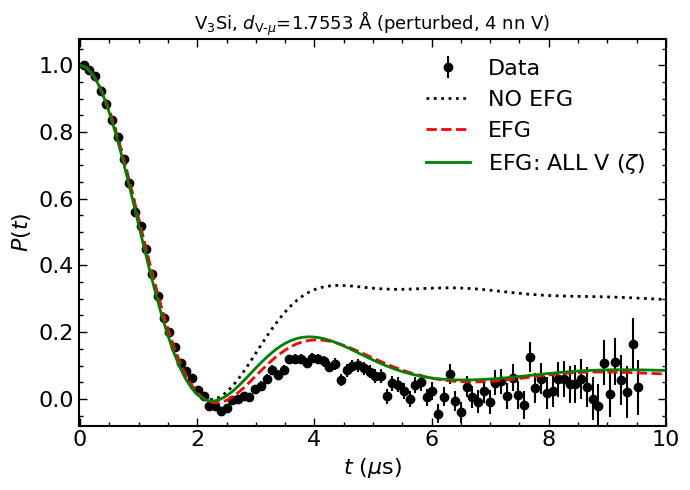

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))

file = 'V3Si_ZFmuSRdata_23K.dat'
file = os.path.join(dpath, file)
data = np.loadtxt(
    file,
    delimiter=",",
    # skiprows=1
)
t = data[:, 0]
y = data[:, 1]
# print(len(y))
# ax.errorbar(t, y, yerr=None, fmt='o', color='k', mfc='white', mec='r', fillstyle=None, ms=6)

file = 'V3Si_ZFmuSRdata_unfiltered_23K.dat'
file = 'V3Si_ZFmuSRdata_unfiltered_23K_v2.dat'
file = os.path.join(dpath, file)
xData, yData, errData = load_raw_data_only(file, x_min=0.0)   # drop the t<0 "prompt" artifact bin
# print(len(yData))
ax.errorbar(xData, yData/yData.max(), yerr=errData/yData.max(), fmt='o', color='k', alpha=1.0, ms=6, label='Data')

# simulations
tlist_us = V3SI_PERTURBED_NEIGHBORS["SIGNALS"]["tlist"]
simulations = V3SI_PERTURBED_NEIGHBORS["SIGNALS"]["data"]["NN"]
ax.errorbar(tlist_us*1e6, simulations['WITHOUT_EFG'], color='k', ls=':', lw=2, label='NO EFG')
ax.errorbar(tlist_us*1e6, simulations['WITH_EFG'], color='r', ls='--', lw=2, label='EFG')
# ax.errorbar(tlist_us*1e6, signals, color='g', ls='--', lw=2, label='10% EFG')
ax.errorbar(tlist_us*1e6, signals, color='g', ls='-', lw=2, label=r'EFG: ALL V ($\zeta$)')

fontsize=16

ax.set_title(r"V$_3$Si, $d_{\mathrm{V}\text{-}{\mu}}$=1.7553 Å (perturbed, 4 nn V)", fontsize=fontsize-3)
# ax.set_title(r"V$_3$Si, $d_{\mathrm{V}\text{-}{\mu}}$=1.7553 Å (perturbed, 4 nn V)", fontsize=fontsize-3)

ax.set_xlabel(r"$t$ ($\mu$s)", fontsize=fontsize)
ax.set_ylabel(r"$P(t)$", fontsize=fontsize)

ax.set_xlim([-0.02, 10.0])
ax.set_ylim([-0.08, 1.08])


for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.minorticks_on()
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=6,
    width=1.0,
    labelsize=fontsize,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=1.0,
)

prop={'size': 16, 'weight':'normal'}
handler_map={
    tuple: matplotlib.legend_handler.HandlerTuple(ndivide=5, pad=1), # ndivide=None
}
_ordered_legend(ax, order_list=('Data', ), prop=prop, frameon=False, handler_map=handler_map)
# ax.legend()

plt.tight_layout()
figname='V3Si_computed_polarization.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

In [25]:
import pickle

simulations = {
    # 'unperturbed': V3SI_UNPERTURBED_NEIGHBORS,
    # 'perturbed': V3SI_PERTURBED_NEIGHBORS,
    'simulation': {
        'unperturbed': V3SI_UNPERTURBED_NEIGHBORS,
        'perturbed': V3SI_PERTURBED_NEIGHBORS,
    },
    'structures': {
        'unperturbed': {'ase': atoms, 'muon': muon_position},
        'perturbed': {'ase': atoms_rlx, 'muon': muon_position_rlx},
    }
}

file = 'V3Si_simulations.pkl'
file = os.path.join(dpath, file)

with open(file, "wb") as f:
    pickle.dump(simulations, f)

# with open(file, "rb") as f:
#     my_dict = pickle.load(f)

In [26]:
file = 'V3Si_QE_RELAX3x3x3_SITE_A.IN'
file = os.path.join(dpath, file)
input_struct = read_from_file(file, format="espresso-in")

file = 'V3Si_QE_RELAX3x3x3_SITE_A.OUT'
file = os.path.join(dpath, file)
final_struct = read_from_file(file, format="espresso-out", index=-1)

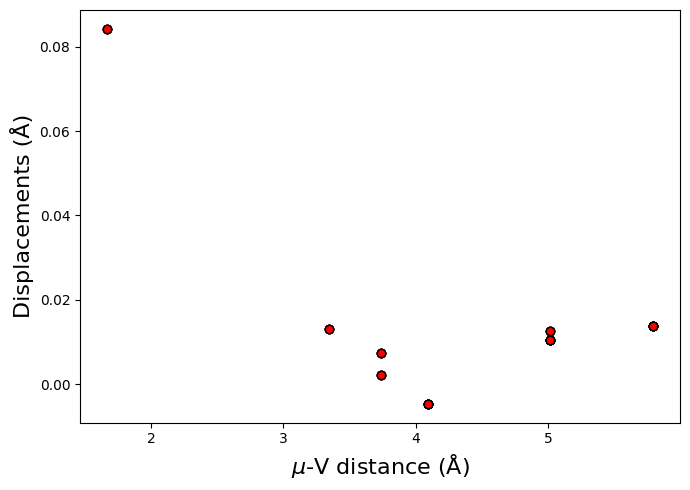

In [27]:
radial_res = radial_to_dict(input_struct, final_struct, muon_label='H')

sel = select_radial_displacement(
    radial_res,
    species='V',
    distance_type='unperturbed',
    cutoff=6.0,          # None -> no cutoff, keep everything
)


fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sel['distance'], sel['displacements'], color='red', edgecolor='k', label='V')

ax.set_xlabel(r'$\mu$-V distance (Å)', fontsize=fontsize)
ax.set_ylabel(r'Displacements (Å)' , fontsize=fontsize)

plt.tight_layout()
plt.show()

In [28]:
max_displacement(input_struct, final_struct)

np.float64(0.08425414971813026)